In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import nltk
from wordcloud import WordCloud,STOPWORDS
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
import re,string,unicodedata
from nltk import pos_tag
from string import punctuation
from sklearn.metrics import classification_report,confusion_matrix,f1_score,accuracy_score
from sklearn.model_selection import train_test_split
import warnings

In [12]:
df = pd.read_csv(
    'IMDB-Dataset.csv',
    sep=',',
    encoding='utf-8',
    engine='python',
    on_bad_lines='skip'
)

In [13]:
df.head()

,Ratings,Reviews,Movies,Resenhas
0,1.0,*Disclaimer: I only watched this movie as a co...,Disaster Movie,* Isenção de responsabilidade: eu só assisti e...
1,1.0,I am writing this in hopes that this gets put ...,Disaster Movie,Estou escrevendo isso na esperança de que isso...
2,1.0,"Really, I could write a scathing review of thi...",Disaster Movie,"Realmente, eu poderia escrever uma crítica con..."
3,1.0,If you saw the other previous spoof movies by ...,Disaster Movie,Se você viu os outros filmes falsificados ante...
4,1.0,This movie I saw a day early for free and I st...,Disaster Movie,Este filme eu vi um dia cedo de graça e ainda ...


In [14]:
df.shape

(150000, 4)

In [15]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words=stopwords.words('english')
new_stop_words=['film','movie','one','would','could','might']
stop_words.extend(new_stop_words)
stop_words.remove('not')
stop_words=set(stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
def remove_special_character(text):
  return re.sub(r'[^a-zA-Z0-9\s]','',text)

def remove_url(text):
  return re.sub(r'http\S+','',text)

def remove_stopwords(text):
  clean_data=[]
  for i in text.split():
    if(i.strip().lower() not in stop_words and i.strip().lower().isalpha()):
      clean_data.append(i.strip().lower())
  return ' '.join(clean_data)

def expand_contractions(text):
  text=re.sub(r'won\'t','will not',text)
  text=re.sub(r'can\'t','can not',text)
  text=re.sub(r'don\'t','do not',text)
  text=re.sub(r'shouldn\'t','should not',text)
  text=re.sub(r'wouldn\'t','would not',text)
  text=re.sub(r'couldn\'t','could not',text)
  text=re.sub(r'isn\'t','is not',text)
  text=re.sub(r'wasn\'t','was not',text)
  text=re.sub(r'weren\'t','were not',text)
  text=re.sub(r'haven\'t','have not',text)
  text=re.sub(r'hasn\'t','has not',text)
  text=re.sub(r'n\'t',' not',text)
  text=re.sub(r'\'re',' are',text)
  text=re.sub(r'\'s',' is',text)
  text=re.sub(r'\'d',' would',text)
  text=re.sub(r'\'ll',' will',text)
  text=re.sub(r'\'ve',' have',text)
  text=re.sub(r'\'m',' am',text)
  return text

In [17]:
def data_cleaning(text):
    text=text.lower()
    text=expand_contractions(text)
    text=remove_url(text)
    text=remove_special_character(text)
    text=remove_stopwords(text)
    return text


In [18]:
df['Reviews']=df['Reviews'].apply(data_cleaning)

In [19]:
df['Reviews'].head()

,Reviews
0,disclaimer watched conditional agreement see f...
1,writing hopes gets put previous review anyone ...
2,really write scathing review turd sandwich ins...
3,saw previous spoof movies two horrible gentlem...
4,saw day early free still feel like got ripped ...


In [20]:
df.isna().sum()

,0
Ratings,0
Reviews,0
Movies,25
Resenhas,0


In [21]:
df['Ratings'].describe()

,Ratings
count,150000.000000
mean,5.500000
std,2.872291
min,1.000000
25%,3.000000
50%,5.500000
75%,8.000000
max,10.000000


In [22]:
df.nunique()

,0
Ratings,10
Reviews,149756
Movies,14206
Resenhas,149774


In [23]:
sentences=df['Reviews']
pos=' '.join(map(str,sentences[df['Ratings']>=7]))
neg=' '.join(map(str,sentences[df['Ratings']<=4]))

In [24]:
len(pos)

47027432

(np.float64(-0.5), np.float64(1499.5), np.float64(799.5), np.float64(-0.5))

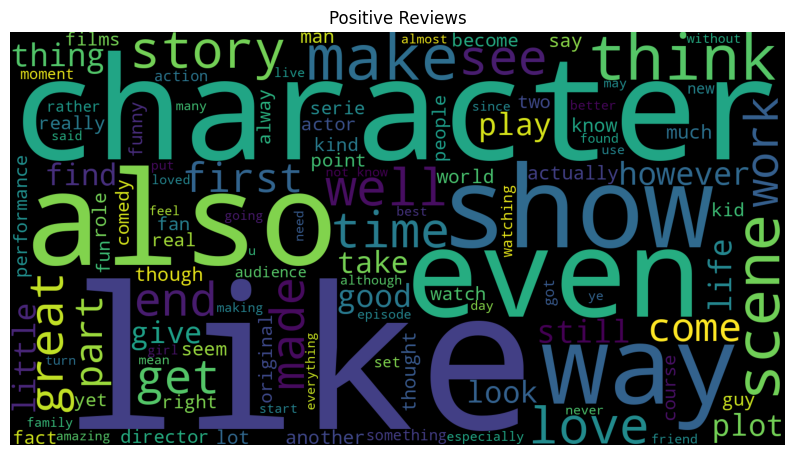

In [25]:
pos_wordcloud=WordCloud(width=1500,height=800,background_color='black',
                        stopwords=stop_words,
                        min_font_size=15).generate(pos)
plt.figure(figsize=(10,10))
plt.imshow(pos_wordcloud)
plt.title('Positive Reviews')
plt.axis('off')

(np.float64(-0.5), np.float64(1499.5), np.float64(799.5), np.float64(-0.5))

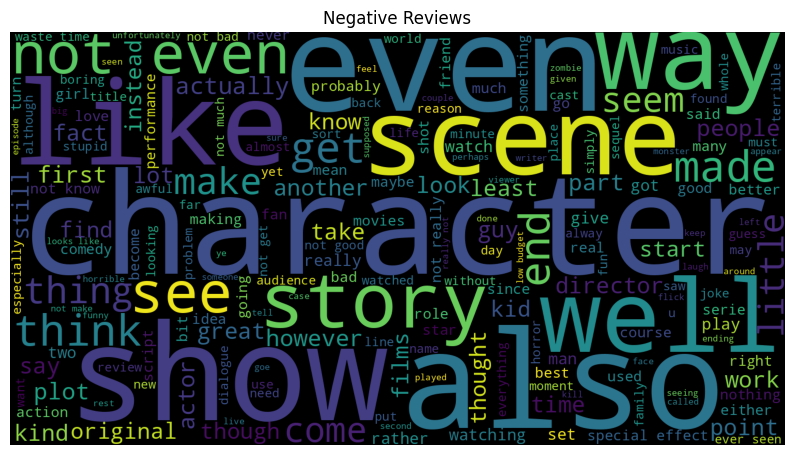

In [26]:
neg_wordcloud=WordCloud(
    width=1500,height=800,
    background_color='black',
    stopwords=stop_words,
    min_font_size=15).generate(neg)
plt.figure(figsize=(10,10))
plt.imshow(neg_wordcloud)
plt.title('Negative Reviews')
plt.axis('off')

Text(0.5, 1.0, 'Negative Reviews')

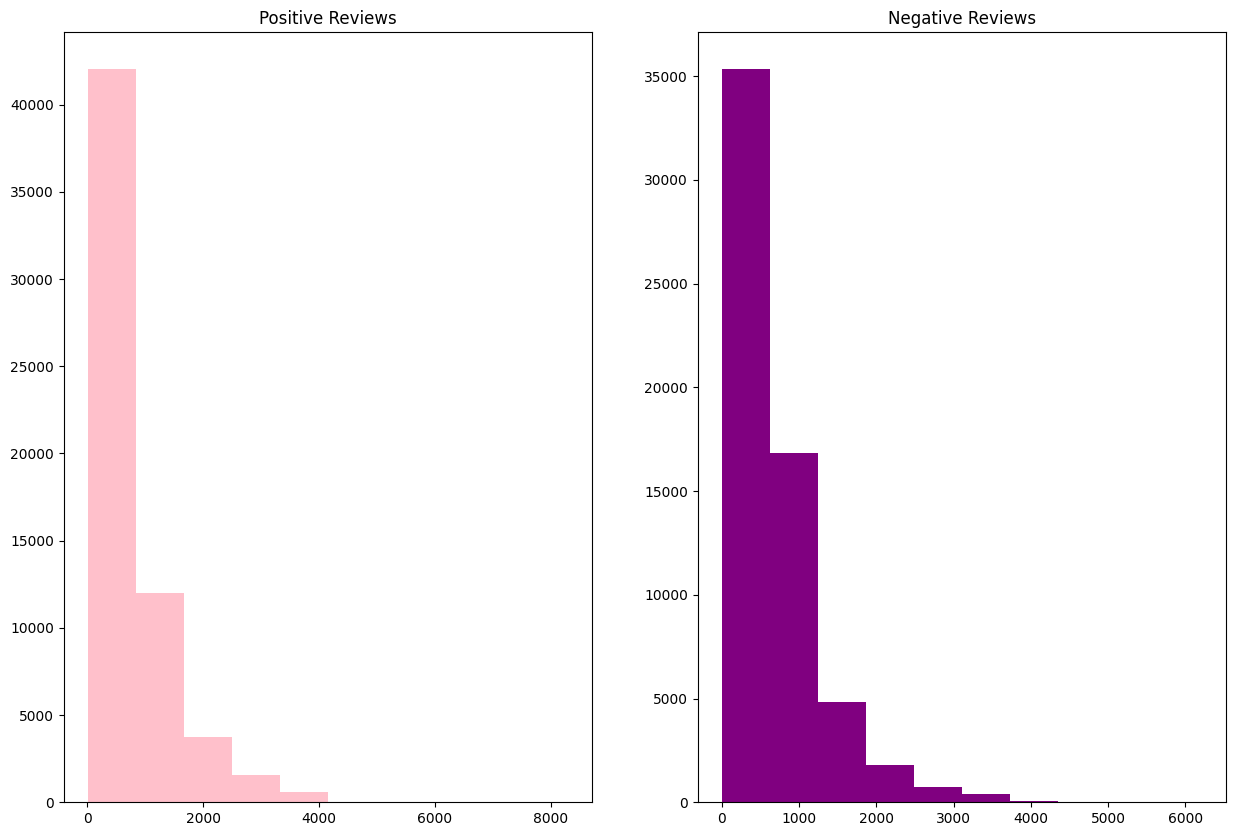

In [27]:
figure,(pos_ax,neg_ax)=plt.subplots(1,2,figsize=(15,10))
len_pos_review=df[df['Ratings']>=7]['Reviews'].str.len()
pos_ax.hist(len_pos_review,color='pink')
pos_ax.set_title('Positive Reviews')
len_neg_review=df[df['Ratings']<=4]['Reviews'].str.len()
neg_ax.hist(len_neg_review,color='purple')
neg_ax.set_title('Negative Reviews')

In [28]:
#get important features using CountVectorizer
def get_top_text_ngrams(corpus,n,g):
  vec=CountVectorizer(ngram_range=(g,g)).fit(corpus)
  bag_of_words=vec.transform(corpus)
  sum_words=bag_of_words.sum(axis=0)
  words_freq=[(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
  words_freq=sorted(words_freq,key=lambda x:x[1],reverse=True)
  return words_freq[:n]

In [29]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

most_common_uni = get_top_text_ngrams(df.Reviews[df['Ratings']>=7],20,1)
most_common_uni = dict(most_common_uni)
temp = pd.DataFrame(columns = ["Common_words" , 'Count'])
temp["Common_words"] = list(most_common_uni.keys())
temp["Count"] = list(most_common_uni.values())
fig = px.bar(temp, x="Count", y="Common_words", title='Commmon Words in Positive Reviews', orientation='h',
             width=700, height=700,color='Common_words')
fig.show()

In [30]:
most_common_bi = get_top_text_ngrams(df.Reviews[df['Ratings']>=7],20,2)
most_common_bi = dict(most_common_bi)
temp = pd.DataFrame(columns = ["Common_words" , 'Count'])
temp["Common_words"] = list(most_common_bi.keys())
temp["Count"] = list(most_common_bi.values())
fig = px.bar(temp, x="Count", y="Common_words", title='Commmon bigram in Positive Reviews', orientation='h',
             width=700, height=700,color='Common_words')
fig.show()

In [31]:
most_common_tri = get_top_text_ngrams(df.Reviews[df['Ratings']>=7],20,3)
most_common_tri = dict(most_common_tri)
temp = pd.DataFrame(columns = ["Common_words" , 'Count'])
temp["Common_words"] = list(most_common_tri.keys())
temp["Count"] = list(most_common_tri.values())
fig = px.bar(temp, x="Count", y="Common_words", title='Commmon trigram in Positive Reviews', orientation='h',
             width=700, height=700,color='Common_words')
fig.show()

In [32]:
pd.options.display.max_colwidth=1000
df[['Reviews','Ratings','Movies']][(df['Ratings']>=7)&(df['Reviews'].str.contains('not like| not want| really not'))].head(10)

,Reviews,Ratings,Movies
90015,honest not watch initially bad reviews professional reviewers yesterday got dvd thought not watch least minutes really surprised enjoyed fist minutes decided watch entire honest blast not bad reviews suggest not know reviewers not like anyhow lets talk story story fine screenplay good dialogues situations okay laughed almost every gag saif role mental guy superb stole show character ram kapoor roles good felt ritesh not get excellent lines deliver got movies like masti dhamaal girls small roles nothing much wonder made serious actor like bipasha type anyhow feel sajid khan good job people watch reviewers not taste like humshakals better story gags compared sajid previous movies enjoy good laugh cheers,7.0,Humshakals
90026,well say imdb junkie day checking bottom list laughs came across future war reading line user comment forced perspective dinosaurs embarked laughing attack find went bought somewhere like bucks pumped dvd player prepared worst not know begin really notthe opening creditsroll truly scary five minutes worth poorlytimed cuts cast characters tech team interspersed recycled bad add space cruiser footage fastforwarded minute first time seeing filmscenes go nowhere like runaway bernhardt walks room says stay near water referring dinotrackers scene cuts frighteningly soon times video quality shattered dark shadows appear top screen sense continuity destroyed poor editing pacingthe lead cyborg z wouldar somebody featured credits also starring like presence tantamount alist talent graciously appearing indie flat corny cyborg ever seen future war tries approach greatness allegedly pulsepounding fight sequences ruined runaway pummels plastic trex size snoopy doll give credit though really look...,7.0,Future War
90035,looking rating reviews given say people getting bit harsh not watch lot bollywood flicks cause times really not let kills extentbut honest though bored moments liked definitely not going classic kind u say worth seeing time must see time not get carried awaya lot flaws admit concept priyanka always kk awesoooooome really liked abut focused not wasted time characters like drona father shown whole story like bolly not waste much time romance enough like hollywood ie pinch strangely first song annoying script ok dialog great visual effects crappy priyanka abhishek good expressions right abut every timei say way ahead times reason not big success generation happy old romantic saga copied hollywood action sequence thrillers not got appreciate definitely suggest readers rent dvd watch homefor,7.0,The Legend of Drona
90039,funny timesperceptions change time last night watching commented kids really not bad imdb gave stars thought disingenuous definite campy feel late madefortv movieminiseries writer pulled together familiar loved scifi plots like day earth stood still twilight zone episode serve man v independence day aliens sounded like dalek even touch mars attacks intents purposes appealed much wider band scifi aficionados kids mainly watching awful cgi felt little let overall either made years late writer paying homage tv movies grew,7.0,Independents' Day
90041,stars bill oberstjr rich goteri written directed jason hull digress abitin critiqued video vhs elves starred dan haggerty santa vs nazi xmas elveswatched every christmas till tape brokekrampus given us new viewing tradition next annual ritual not want spoilers butsanta krampus along demon actually well told script cop naughty list grew lots violence cool deathsis oxymoron statement winter equals snow locale adds lots look makings cult filmwould build better poster maybe push great soundtrack,7.0,Krampus: The Christmas Devil
90042,way vampire begins around turn century england abraham van helsing rhett giles immortal assembled gang vampire slayers not scooby gang like buffy first minutes gang slaughtered van helsing decapitates dracula dracula gang left temporary chaos prince replace sebastien andreas beckett mistaken van hel

In [33]:
most_common_uni_n=get_top_text_ngrams(df.Reviews[df['Ratings']<=4],20,1)
most_common_uni_n=dict(most_common_uni_n)
temp = pd.DataFrame(columns=["Common_words" , 'Count'])
temp["Common_words"] = list(most_common_uni_n.keys())
temp["Count"] = list(most_common_uni_n.values())
fig = px.bar(temp, x="Count", y="Common_words", title='Commmon Words in Negative Reviews', orientation='h',
             width=700, height=700,color='Common_words')
fig.show()

In [34]:
most_common_bi_n=get_top_text_ngrams(df.Reviews[df['Ratings']<=4],20,2)
most_common_bi_n=dict(most_common_bi_n)
temp = pd.DataFrame(columns=["Common_words" , 'Count'])
temp["Common_words"] = list(most_common_bi_n.keys())
temp["Count"] = list(most_common_bi_n.values())
fig = px.bar(temp, x="Count", y="Common_words", title='Commmon Words in Negative Reviews', orientation='h',
             width=700, height=700,color='Common_words')
fig.show()

In [35]:
most_common_tri_n=get_top_text_ngrams(df.Reviews[df['Ratings']<=4],20,3)
most_common_tri_n=dict(most_common_tri_n)
temp = pd.DataFrame(columns=["Common_words" , 'Count'])
temp["Common_words"] = list(most_common_tri_n.keys())
temp["Count"] = list(most_common_tri_n.values())
fig = px.bar(temp, x="Count", y="Common_words", title='Commmon Words in Negative Reviews', orientation='h',
             width=700, height=700,color='Common_words')
fig.show()

In [36]:
pd.options.display.max_colwidth=1000
df[["Reviews","Ratings","Movies"]][(df['Ratings']<=4)&(df['Reviews'].str.contains("good|great"))].head(100)

,Reviews,Ratings,Movies
3,saw previous spoof movies two horrible gentlemen know already bad tell truth want watch brainless person ironically meant stereotypical teenagers not laugh bit judge even little automatically fails never ask comes two menremember good old hollywood days whenever making showing people type art also story kept edge seat well whenever word hit making films earned loads cash greedy people came picture quite pathetic two exception still artists notably genius christopher nolan two guys justwell writing big words let put simple terms guysthese guys suck not artists instead money craving whores latest proves even sothe fails easily mind blowing mean nothing funny trailer people usually put best stuff like idiots sometimesi knew going bad made bet friends not good idea write reviews paper tell everyone whats good whats bad friends flipped review itwhy well warning least not even called nothing artistic original jokesi sorry references made throughout pretty much random like hannah montana ...,1.0,Disaster Movie
6,given free ticket not complain ripped except minutes life irretrievably stolen sort movies date epic meet spartans not funny time disaster reached new low not real laugh anywhere alleged jokes actually painful considerable amount childish meanspirited stuff form racist sexist especially homophobic garbage present along ample helpings juvenile grossouts none actors even bothering put pretense acting nothing hip clever even mildly intelligent going entire beginning end crass vulgar irrational utterly humorless human sense know past sort trash made enough money keep seltzer et al grinding disaster may downfall franchise utter contempt seltzer collaborators audience finally beginning show clearly fails saw almost empty theater good chance seltzer go back drawing board stop making lazy catastrophes finally develop real sense humor unfunny piece puke stay away,1.0,Disaster Movie
7,ok disastrous not imaginative barb not shred wit soi saw free friend said pissed pants trailer free passes think incontinenta spoof disaster movies fun not couple disaster movies get referenced not really spoofed instead spoofing recent movies genres aspects current popculture current women wrestling head commercialsif anything good minute running time get minutes nicole parker seems like good good material,1.0,Disaster Movie
11,decided go see friends laugh hoping bad become funny awful cant take kid seriouslyalso confirmed knew jb ego even bigger kayne west entire like look talented singer good person simply nothing not dowhat forgot mention mommies fat cigar smoking managers made jb puppet make look better buried deeper starting think done purpose fat cats want get rid himwould not recommend,1.0,Justin Bieber: Never Say Never
12,right everyone imdb pretty much committed giving movieif call get bottom list trust righti went see knew way criticize without seeing ithowever lacks artistic merit whatsoever full latest greatest pop sensations youtube generation names flashy lights stuffing cooked turkey showat heart presentation message never give dreams however whole bieber smiling looking pretty grooming lesbian hair mentioned previous reviews theater full tween girls screaming heads every time inhaled exhaled someone really needs teach modern generation cinema etiquette least tell shut seconds honestly not know trying besides earn money add accolades stars names short pointlessthe also sucks,1.0,Justin Bieber: Never Say Never
...,...,...,...
238,remember young child acquainted internet learning lawrence kasanoff foodfight seemed unlike anything ever heard combining dozens popular advertising mascots mr clean chester cheetah mrs buttersworth charlie tuna resemble toy story setting transferred supermarket story actually cinema animation baffling stories time development hell still captivates whenever scour internet looking summation exactly went picture story incredible ambition controversy unfathomably disappointing conclusion not 

##Feature Engineering

In [37]:
df=df[(df['Ratings']!=5) & (df['Ratings']!=6)].copy()

In [38]:
df['Sentiment']=(df['Ratings'] >= 7).astype(int)


In [39]:
data=df[['Reviews','Sentiment']]

In [40]:
data['Sentiment'].value_counts()

,count
Sentiment,
0,60000
1,60000


In [41]:
import sys
import os
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from prettytable import PrettyTable
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize

###Lemmatization

In [42]:
class LemmatizingTokenizer:

  def __init__(self):
    self.lemmatizer=WordNetLemmatizer()

  def __call__(self,text):
    tokens=word_tokenize(text)
    lemmatized_tokens=[self.lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens


###Vectorization with CountVector and TFIDF Vectorizer

In [43]:
train,test=train_test_split(data,test_size=0.2,random_state=42,shuffle=True)

In [44]:
count_vect=CountVectorizer(
    analyzer='word',#tokenize by words not characters
    tokenizer=LemmatizingTokenizer(),#use the class to normalize words
    ngram_range=(1,1),#unigrams and bigrams
    min_df=10,#ignore words that appear in less than 10 documents
    max_features=500#keep only top 500 words by frequency
)

In [45]:
tfidf_vect=TfidfVectorizer(
    analyzer='word',
    tokenizer=LemmatizingTokenizer(),
    ngram_range=(1,1),
    min_df=10,
    max_features=500
)

In [46]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [47]:
X_train_count=count_vect.fit_transform(train['Reviews']).toarray()
X_test_count=count_vect.transform(test['Reviews']).toarray()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



In [48]:
X_train_tfidf=tfidf_vect.fit_transform(train['Reviews']).toarray()
X_test_tfidf=tfidf_vect.transform(test['Reviews']).toarray()

In [49]:
y_train=train['Sentiment']
y_test=test['Sentiment']

###Feature Importance with Logistic Regression and CountVectorizer

In [50]:
lr=LogisticRegression()
lr.fit(X_train_count,y_train)

LogisticRegression()

In [51]:
lr.score(X_test_count,y_test)

0.8315833333333333

In [52]:
lr.coef_[0]

array([ 1.19027879e-01,  3.43489561e-02, -1.65806468e-01, -1.72721327e-01,
        2.74820374e-01, -1.32647748e-01, -1.35999358e-01, -4.95445689e-02,
        4.22886030e-02,  9.09177616e-02,  1.04411837e-01, -7.33035625e-02,
       -1.08446161e-02,  1.05716624e-01, -2.00747898e-01,  1.20531750e-01,
        1.99000814e-01,  1.89178996e-01,  8.53724868e-01,  4.49619665e-02,
       -7.86981918e-01, -1.49891860e-01, -4.62766998e-02, -2.98082201e-01,
       -9.92944261e-02,  9.49132029e-04, -6.17701094e-01,  3.16136598e-01,
       -1.17116085e-02, -2.54080652e-01,  4.16413322e-02, -1.18705984e+00,
        3.46961160e-02, -3.54474833e-01,  1.11350287e-01,  4.09334198e-01,
        9.92342244e-02, -9.78988429e-02,  9.84486447e-03,  1.76582878e-01,
       -3.27870564e-02, -2.60830451e-03,  4.22243145e-01, -5.52865642e-02,
       -2.64425959e-02,  2.12826199e-01, -5.81806561e-02, -7.54097413e-02,
       -3.29700039e-02, -5.20878405e-02, -1.09213504e+00,  1.80410393e-02,
        9.13628396e-01,  

In [53]:
i=0
important_feature=PrettyTable(['Feature','Score'])
for feature,importance in zip(count_vect.get_feature_names_out(),lr.coef_[0]):
  if i <= 200:
        important_feature.add_row([feature, importance])
        i = i + 1
print(important_feature)

+----------------+------------------------+
|    Feature     |         Score          |
+----------------+------------------------+
|      able      |  0.11902787916446744   |
|   absolutely   |  0.034348956094475615  |
|      act       |  -0.16580646842139202  |
|     acting     |  -0.17272132703258203  |
|     action     |  0.27482037449496655   |
|     actor      |  -0.1326477475695415   |
|    actress     |  -0.13599935808582128  |
|    actually    |  -0.04954456894813816  |
|      add       |  0.04228860299332942   |
|     adult      |  0.09091776156071713   |
|      age       |  0.10441183690195602   |
|     alien      |  -0.07330356249883964  |
|     almost     | -0.010844616057536904  |
|     along      |  0.10571662418691699   |
|    already     |  -0.2007478977386152   |
|      also      |  0.12053175009479955   |
|    although    |  0.19900081419161758   |
|     always     |   0.1891789956617649   |
|    amazing     |   0.8537248680188426   |
|    american    |   0.044961966

###Feature Importance with Logistic Regression and TFIDF vectorizer

In [54]:
lr2=LogisticRegression()
lr2.fit(X_train_tfidf,y_train)
lr2.score(X_test_tfidf,y_test)
lr2.coef_[0]

array([ 5.56604839e-01,  3.18540205e-01, -1.06260298e+00, -1.51202886e+00,
        2.59870074e+00, -1.37429542e+00, -8.32719141e-01, -3.76594766e-01,
        1.25263383e-01,  8.15932405e-01,  8.32481308e-01, -3.23520017e-01,
       -2.30386983e-01,  6.23133781e-01, -1.09521608e+00,  1.36006331e+00,
        1.10544081e+00,  1.59494955e+00,  4.68823929e+00,  4.00673910e-01,
       -3.95836331e+00, -1.22646280e+00, -2.73723313e-01, -2.13360754e+00,
       -7.47597195e-01,  3.52526130e-01, -3.75887703e+00,  1.78415192e+00,
        3.35562232e-01, -9.93188986e-01,  3.72128962e-01, -6.77260969e+00,
        2.79017484e-01, -3.65602614e+00,  6.00621918e-01,  2.72525072e+00,
        7.73116770e-01, -6.21526463e-01, -5.49366399e-02,  9.10005770e-01,
       -3.25911445e-03, -3.16551507e-02,  3.70018713e+00, -4.68704676e-01,
       -1.02315744e-01,  1.85695276e+00, -1.81716287e-01, -3.86302268e-01,
       -2.43117483e-01,  7.88123162e-02, -6.39729511e+00,  2.68042768e-01,
        4.70425098e+00,  

In [55]:
i=0
important_feature=PrettyTable(['Feature','Score'])
for feature,importance in zip(tfidf_vect.get_feature_names_out(),lr2.coef_[0]):
  if i<=200:
    important_feature.add_row([feature,importance])
    i=i+1
print(important_feature)

+----------------+------------------------+
|    Feature     |         Score          |
+----------------+------------------------+
|      able      |   0.5566048386576142   |
|   absolutely   |   0.3185402046181347   |
|      act       |  -1.0626029767812672   |
|     acting     |  -1.5120288628563634   |
|     action     |    2.59870074156349    |
|     actor      |   -1.374295421822771   |
|    actress     |  -0.8327191411217432   |
|    actually    |  -0.3765947661401619   |
|      add       |   0.1252633828222333   |
|     adult      |   0.8159324052836613   |
|      age       |   0.8324813081393422   |
|     alien      |  -0.3235200166183515   |
|     almost     |  -0.23038698345920358  |
|     along      |   0.6231337813687383   |
|    already     |  -1.0952160772562831   |
|      also      |   1.3600633051884554   |
|    although    |   1.1054408062400418   |
|     always     |   1.5949495503618631   |
|    amazing     |   4.688239291608919    |
|    american    |  0.4006739100

###Repeating for bigrams

In [56]:
count_vect_bigram = CountVectorizer(
    analyzer='word',
    tokenizer=LemmatizingTokenizer(),
    ngram_range=(2,2),
    min_df=10,
    max_features=500
)

tfidf_vect_bigram = TfidfVectorizer(
    analyzer='word',
    tokenizer=LemmatizingTokenizer(),
    ngram_range=(2,2),
    min_df=10,
    max_features=500
)

In [57]:
X_train_count_bigram = count_vect_bigram.fit_transform(train['Reviews']).toarray()
X_test_count_bigram  = count_vect_bigram.transform(test['Reviews']).toarray()

X_train_tfidf_bigram = tfidf_vect_bigram.fit_transform(train['Reviews']).toarray()
X_test_tfidf_bigram  = tfidf_vect_bigram.transform(test['Reviews']).toarray()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



In [58]:
def get_top_features(model, vectorizer, top_n=20):
    coefs=model.coef_[0]
    features=vectorizer.get_feature_names_out()

    feat_df=pd.DataFrame({'feature':features,'coef':coefs})

    top_pos=feat_df.sort_values('coef',ascending=False).head(top_n)

    top_neg=feat_df.sort_values('coef',ascending=True).head(top_n)

    table=PrettyTable(['Feature','Score'])
    for _,row in pd.concat([top_pos,top_neg]).iterrows():
        table.add_row([row['feature'],row['coef']])
    print(table)

In [59]:
#Logistic Regression for CountVectorizer (bigrams)
lr_count=LogisticRegression()
lr_count.fit(X_train_count_bigram,y_train)
lr_count.score(X_test_count_bigram,y_test)
print('\n Top Features (CountVectorizer)')
get_top_features(lr_count,count_vect_bigram)


 Top Features (CountVectorizer)
+----------------------+---------------------+
|       Feature        |        Score        |
+----------------------+---------------------+
|   definitely worth   |  2.3727957072569534 |
| pleasantly surprised |  2.310978474356606  |
|      well worth      |  2.277823434412201  |
|     not perfect      |  2.147332867190543  |
|   highly recommend   |  1.9763901196826044 |
|      must watch      |  1.8416828475827496 |
|     not everyone     |  1.834718625903172  |
|   negative review    |   1.81420892016703  |
|      edge seat       |  1.8032058765601227 |
|      best ever       |  1.7425767487072792 |
|    not disappoint    |  1.720937170091582  |
|    really enjoyed    |  1.6848904976068997 |
|       must see       |  1.6289158028149968 |
|      great job       |  1.5806997727754526 |
|      also great      |  1.5002269562943278 |
|  great performance   |  1.4765268578321826 |
|     acting great     |  1.3957885255268747 |
|     even better      |  1

In [60]:
#Logistic Regression for TFIDFVectorizer (bigrams)
lr_tfidf=LogisticRegression()
lr_tfidf.fit(X_train_tfidf_bigram,y_train)
lr_tfidf.score(X_test_tfidf_bigram,y_test)
print('\n Top Features (TFIDFVectorizer)')
get_top_features(lr_tfidf,tfidf_vect_bigram)


 Top Features (TFIDFVectorizer)
+----------------------+---------------------+
|       Feature        |        Score        |
+----------------------+---------------------+
| pleasantly surprised |  4.6417724560614335 |
|   definitely worth   |  4.375979939963848  |
|     not perfect      |  4.369256413877962  |
|      well worth      |  4.312889959474069  |
|   highly recommend   |  3.918935539574245  |
|   negative review    |  3.7275209633313167 |
|    really enjoyed    |  3.6544909360791134 |
|      edge seat       |  3.615687675664393  |
|      great job       |  3.5437682673477244 |
|     not everyone     |  3.415308565566132  |
|      best ever       |  3.3367651756034005 |
|    not disappoint    |  3.290545738373469  |
|      must watch      |  3.2254897140095435 |
|       must see       |  3.204089087214165  |
|   not disappointed   |  2.988042486677873  |
|      bad review      |  2.9627002226743646 |
|     well written     |  2.886249421574149  |
|  great performance   |  2

###Repeating for trigrams

In [61]:
count_vect_trigram = CountVectorizer(
    tokenizer=LemmatizingTokenizer(),
    ngram_range=(3,3),   # trigrams only
    min_df=10,
    max_features=500
)
tfidf_vect_trigram = TfidfVectorizer(
    tokenizer=LemmatizingTokenizer(),
    ngram_range=(3,3),
    min_df=10,
    max_features=500
)

In [62]:
X_train_count_trigram = count_vect_trigram.fit_transform(train['Reviews']).toarray()
X_test_count_trigram  = count_vect_trigram.transform(test['Reviews']).toarray()
X_train_tfidf_trigram = tfidf_vect_trigram.fit_transform(train['Reviews']).toarray()
X_test_tfidf_trigram  = tfidf_vect_trigram.transform(test['Reviews']).toarray()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



In [63]:
lr_count_tri = LogisticRegression(max_iter=1000)
lr_count_tri.fit(X_train_count_trigram, y_train)
print("Accuracy (CountVectorizer Trigrams):", lr_count_tri.score(X_test_count_trigram, y_test))
print("\nTop Features (CountVectorizer Trigrams):")
get_top_features(lr_count_tri, count_vect_trigram, top_n=20)

Accuracy (CountVectorizer Trigrams): 0.602875

Top Features (CountVectorizer Trigrams):
+---------------------------+---------------------+
|          Feature          |        Score        |
+---------------------------+---------------------+
|   vote seventitle brazil  |  3.7217408050603336 |
|   vote eighttitle brazil  |  3.296156123228615  |
|   definitely worth watch  |  2.9944155522130433 |
|   vote ninetitle brazil   |  2.9075852649141414 |
|  highly recommend anyone  |  2.754724760003396  |
|  definitely worth seeing  |  2.7364553956354345 |
| definitely worth watching |  2.6694414489652343 |
|     well worth seeing     |  2.603270105404568  |
|    well worth watching    |  2.5794682483020424 |
| graphic violence language |  2.5779407407838204 |
|      really good job      |  2.545710503322063  |
|   recommend anyone like   |  2.455652759720483  |
|      well worth time      |  2.385564503240888  |
|       kept edge seat      |  2.3014357990262986 |
|    many negative review   

In [64]:
lr_tfidf_tri = LogisticRegression(max_iter=1000)
lr_tfidf_tri.fit(X_train_tfidf_trigram, y_train)

LogisticRegression(max_iter=1000)

In [65]:
print("Accuracy (TF-IDF Trigrams):", lr_tfidf_tri.score(X_test_tfidf_trigram, y_test))
print("\nTop Features (TF-IDF Trigrams):")
get_top_features(lr_tfidf_tri, tfidf_vect_trigram, top_n=20)

Accuracy (TF-IDF Trigrams): 0.603125

Top Features (TF-IDF Trigrams):
+---------------------------+---------------------+
|          Feature          |        Score        |
+---------------------------+---------------------+
|   vote seventitle brazil  |  4.019988647369066  |
|   vote eighttitle brazil  |  3.381802678458421  |
|   definitely worth watch  |  3.124020704104876  |
| definitely worth watching |  3.0085814267590423 |
|   vote ninetitle brazil   |  2.9324159899581166 |
|  highly recommend anyone  |  2.816475165484851  |
|  definitely worth seeing  |  2.7635482670791016 |
|    well worth watching    |  2.7007012635744956 |
| graphic violence language |  2.642480061410028  |
|      really good job      |  2.637340507172009  |
|     well worth seeing     |  2.628282521991056  |
|      best movie ever      |  2.621456371468854  |
|   recommend anyone like   |  2.4899463211678907 |
|       kept edge seat      |  2.484856260221235  |
|       sit back enjoy      |  2.3962876023375

###Feature Selection with Chi Squared

In [66]:
from sklearn.feature_selection import chi2

def top_chi2_features(X, y, vectorizer, n_top=20):
    chi2_scores, p_values = chi2(X, y)
    features = np.array(vectorizer.get_feature_names_out())
    indices = np.argsort(chi2_scores)[::-1]  # descending
    features = features[indices]

    # Split by n-gram
    unigrams = [f for f in features if len(f.split(' ')) == 1][:n_top]
    bigrams  = [f for f in features if len(f.split(' ')) == 2][:n_top]
    trigrams = [f for f in features if len(f.split(' ')) == 3][:n_top]

    return unigrams, bigrams, trigrams

In [67]:
counter = 1
for category in train['Sentiment'].unique():
    print(f"\n=== Class {category} ===")

    # Unigrams
    uni, bi, tri = top_chi2_features(X_train_tfidf, train['Sentiment']==category, tfidf_vect)
    print("\nTop Unigrams:")
    print("\t. " + "\n\t. ".join(uni))

    # Bigrams
    uni_b, bi_b, tri_b = top_chi2_features(X_train_tfidf_bigram, train['Sentiment']==category, tfidf_vect_bigram)
    print("\nTop Bigrams:")
    print("\t. " + "\n\t. ".join(bi_b))

    # Trigrams
    uni_t, bi_t, tri_t = top_chi2_features(X_train_tfidf_trigram, train['Sentiment']==category, tfidf_vect_trigram)
    print("\nTop Trigrams:")
    print("\t. " + "\n\t. ".join(tri_t))

    counter += 1


=== Class 0 ===

Top Unigrams:
	. worst
	. great
	. waste
	. bad
	. awful
	. terrible
	. boring
	. loved
	. poor
	. enjoyed
	. excellent
	. worse
	. perfect
	. nothing
	. horrible
	. amazing
	. fun
	. minute
	. love
	. money

Top Bigrams:
	. waste time
	. not even
	. not waste
	. worst ever
	. bad acting
	. not worth
	. really enjoyed
	. look like
	. great job
	. highly recommend
	. well done
	. really bad
	. even worse
	. must see
	. go see
	. pleasantly surprised
	. acting bad
	. well worth
	. not funny
	. edge seat

Top Trigrams:
	. not waste time
	. worst ever seen
	. worst movie ever
	. waste time money
	. vote seventitle brazil
	. bad acting bad
	. not wait see
	. not worth time
	. not waste money
	. not recommend anyone
	. complete waste time
	. vote threetitle brazil
	. not make sense
	. not even worth
	. vote eighttitle brazil
	. not even good
	. never get back
	. bad not even
	. mystery science theater
	. vote fourtitle brazil

=== Class 1 ===

Top Unigrams:
	. worst
	. grea

###Model Selection


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [69]:
models={
    "Logistic Regression":LogisticRegression(max_iter=200),
    "Decision Tree":DecisionTreeClassifier(max_depth=11),
    "Random Forest":RandomForestClassifier(),
    "AdaBoost":AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=4),
        n_estimators=100,
        learning_rate=0.8
    )
}

In [70]:
results={}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_tfidf,y_train)

    y_pred_train=model.predict(X_train_tfidf)
    y_pred_test =model.predict(X_test_tfidf)

    train_f1=f1_score(y_train, y_pred_train, average="weighted")
    test_f1=f1_score(y_test, y_pred_test, average="weighted")
    test_acc=accuracy_score(y_test, y_pred_test)

    print(f"Train F1 Score: {train_f1:.4f}")
    print(f"Test  F1 Score: {test_f1:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")

    results[name] = test_f1



Training Logistic Regression...
Train F1 Score: 0.8399
Test  F1 Score: 0.8331
Test Accuracy : 0.8331

Training Decision Tree...
Train F1 Score: 0.7372
Test  F1 Score: 0.7076
Test Accuracy : 0.7117

Training Random Forest...
Train F1 Score: 0.9998
Test  F1 Score: 0.8057
Test Accuracy : 0.8057

Training AdaBoost...
Train F1 Score: 0.8284
Test  F1 Score: 0.8132
Test Accuracy : 0.8132


In [71]:
best_model_name=max(results, key=results.get)
print(f"Best Model: {best_model_name}")
print(f"Best F1 Score: {results[best_model_name]:.4f}")

Best Model: Logistic Regression
Best F1 Score: 0.8331


FINAL MODEL: Logistic Regression (TF-IDF Unigrams)
Accuracy : 0.8331
F1 Score : 0.8331

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83     12201
    Positive       0.83      0.84      0.83     11799

    accuracy                           0.83     24000
   macro avg       0.83      0.83      0.83     24000
weighted avg       0.83      0.83      0.83     24000



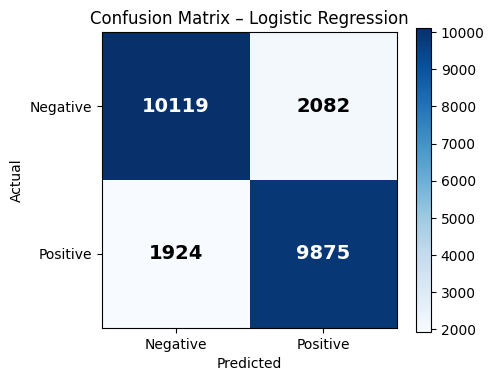

In [72]:
print("FINAL MODEL: Logistic Regression (TF-IDF Unigrams)")
final_model = LogisticRegression(max_iter=200)
final_model.fit(X_train_tfidf, y_train)
y_pred = final_model.predict(X_test_tfidf)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticklabels(['Negative', 'Positive'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix – Logistic Regression')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

In [73]:
def predict_sentiment(reviews: list[str]) -> pd.DataFrame:
    cleaned    = [data_cleaning(r) for r in reviews]
    vectorized = tfidf_vect.transform(cleaned).toarray()
    preds      = final_model.predict(vectorized)
    probs      = final_model.predict_proba(vectorized)
    return pd.DataFrame({
        'Review':     reviews,
        'Sentiment':  ['Positive' if p == 1 else 'Negative' for p in preds],
        'Confidence': [f"{max(p)*100:.1f}%" for p in probs]
    })

In [74]:
sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story was captivating.",
    "Terrible film. Waste of time. The plot made no sense and acting was awful.",
    "It was okay, not the best I have seen but certainly not the worst.",
    "A masterpiece! One of the best films of the decade, highly recommended.",
    "Boring and predictable. I almost fell asleep halfway through."
]

pd.options.display.max_colwidth = 80
print("\n\nSAMPLE PREDICTIONS\n")
print(predict_sentiment(sample_reviews).to_string(index=False))




SAMPLE PREDICTIONS

                                                                                   Review Sentiment Confidence
This movie was absolutely fantastic! The acting was superb and the story was captivating.  Positive      89.9%
               Terrible film. Waste of time. The plot made no sense and acting was awful.  Negative     100.0%
                       It was okay, not the best I have seen but certainly not the worst.  Negative      91.7%
                  A masterpiece! One of the best films of the decade, highly recommended.  Positive      97.3%
                            Boring and predictable. I almost fell asleep halfway through.  Negative      99.8%


In [77]:
import pickle

In [78]:
artifacts = {
    'model': final_model,        # Logistic Regression model
    'vectorizer': tfidf_vect,    # TF-IDF vectorizer (fitted)
    'stop_words': stop_words     # Custom stop words set
}

In [79]:
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

In [80]:
from google.colab import files
files.download('sentiment_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>